In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import sys
sys.path.append('..')
import bets
import os
import glob
import datetime as dt
import time
#import ot
import json
import requests
import statsmodels.api as sm 
from tqdm import tqdm
pd.set_option('display.float_format', lambda x: '%.3f' % x)

nba = bets.nba()
import seaborn as sns
import matplotlib.pyplot as plt
import re
from warnings import simplefilter
simplefilter(action="ignore", category=pd.errors.PerformanceWarning)
from nba_api.stats.endpoints import leaguegamefinder,BoxScoreSummaryV2,LeagueDashOppPtShot,PlayerProfileV2,GameRotation,LeagueDashPlayerShotLocations

In [3]:
# want to get all of '16 as this will fill in '17 start, which will be the beginning of our dataset

In [4]:
def update_view(viewName,file):
    try:
        nba.conn.execute('DROP VIEW {}'.format(viewName))
        nba.conn.commit()
    except:
        '{} does not exist'.format(viewName)
    nba.conn.execute(open(file,'r').read())
    nba.conn.commit()
    print('{} View has been updated'.format(viewName))

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


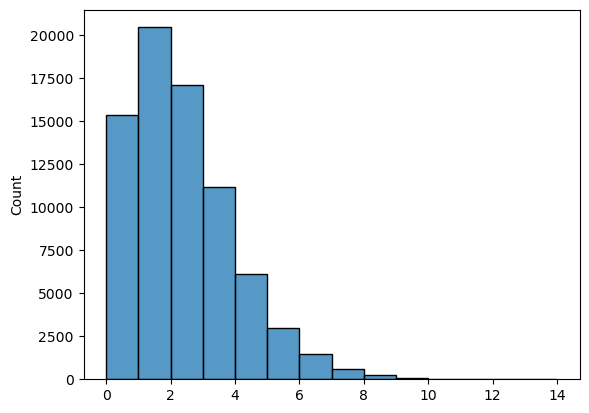

In [1083]:
#what are the distribution of of threes made
sns.histplot(data.threesMade.values,binwidth=1)
plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


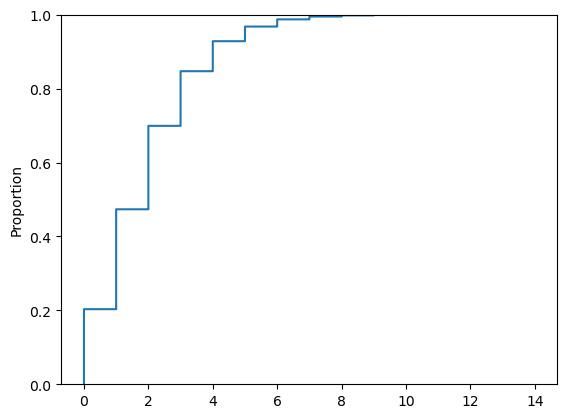

In [1085]:
sns.ecdfplot(data.threesMade.values)
plt.show()

In [1086]:
data.threesMade.describe(percentiles = np.arange(.05,1,.05))

count   75693.000
mean        1.902
std         1.623
min         0.000
5%          0.000
10%         0.000
15%         0.000
20%         0.000
25%         1.000
30%         1.000
35%         1.000
40%         1.000
45%         1.000
50%         2.000
55%         2.000
60%         2.000
65%         2.000
70%         3.000
75%         3.000
80%         3.000
85%         4.000
90%         4.000
95%         5.000
max        14.000
Name: threesMade, dtype: float64

In [1087]:
data.threesMade.value_counts(normalize=True) *100

threesMade
1    27.028
2    22.574
0    20.319
3    14.787
4     8.116
5     3.962
6     1.947
7     0.760
8     0.317
9     0.106
10    0.050
11    0.026
12    0.004
13    0.003
14    0.001
Name: proportion, dtype: float64

In [1088]:
(data.threesMade  >= round(data.careerAvgThrees+.5,0)).sum()

35516

In [1093]:
#how often is someone 1,2,3 over their average? 
data[(data.threesMade  >= round(data.careerAvgThrees+1.5,0)) & (data.game_date>='2018-01-01')].season.value_counts()

season
2023-24    3082
2021-22    2917
2022-23    2803
2020-21    2693
2019-20    2495
2018-19    2403
2017-18    1337
Name: count, dtype: int64

In [789]:
data[(data.threesMade  >= round(data.careerAvgThrees+1.5,0)) & (data.game_date>='2018-01-01')].season.value_counts()

season
2023-24    3075
2021-22    2907
2022-23    2782
2020-21    2655
2019-20    2472
2018-19    2369
2017-18    1321
Name: count, dtype: int64

In [1413]:
idCols = ['name', 'team', 'game_number', 'season', 'player_id', 'team_id','opp_id',
       'game_id', 'game_date','teamfirst10','plyrGameCt','tmGameCt']
fgaCols = ['abv_fga','crn_fga','mid_fga','ra_fga','paint_fga']  
X = final.filter([col for col in final.columns if col not in idCols+['threesMade']])
y = final.threesMade


In [1096]:
X

,height,exp,age,daysBetweenGames,gamesInFive,gamesInThree,oppGamesFive,oppGamesThree,oppDaysLastGame,home,...,crn_fgallowedskew,crn_fgallowedkurt,abv_fgallowedst,abv_fgallowednd,abv_fgallowedrd,abv_fgallowedrth,abv_fgallowedfth,abv_fgallowedxth,abv_fgallowedskew,abv_fgallowedkurt
0,80,12,31.324,9.000,1,1,1,1,9.000,1,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,80,12,31.324,1.000,2,2,2,2,1.000,0,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,80,12,31.324,4.000,1,1,3,2,1.000,0,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,80,12,31.324,1.000,2,2,3,2,1.000,0,...,-0.518,-1.687,18.500,22.500,24.000,25.000,28.000,30.000,-0.323,0.047
4,80,12,31.324,1.000,3,2,2,2,1.000,0,...,0.920,0.317,19.500,20.000,20.000,21.500,25.500,28.000,1.462,1.671
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75688,81,20,38.790,0.000,3,2,3,2,0.000,1,...,1.022,0.617,19.500,21.500,25.000,28.000,29.500,33.000,-0.206,-0.777
75689,81,20,38.790,2.000,3,1,3,1,2.000,0,...,0.719,-0.536,22.500,23.000,24.000,25.000,26.500,35.000,0.461,1.936
75690,81,20,38.790,2.000,2,1,3,2,1.000,0,...,-0.228,-0.043,22.500,23.500,26.000,30.000,31.000,38.000,0.682,-0.336
75691,81,20,38.790,2.000,2,1,3,2,1.000,1,...,0.380,-0.917,23.500,24.000,26.000,28.500,30.500,35.000,0.310,-0.432


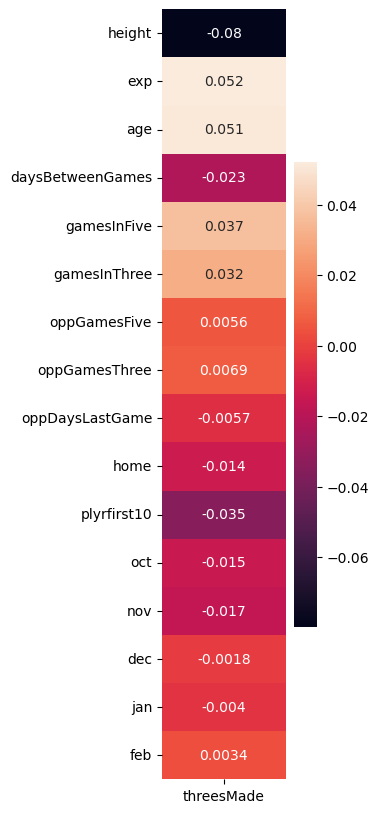

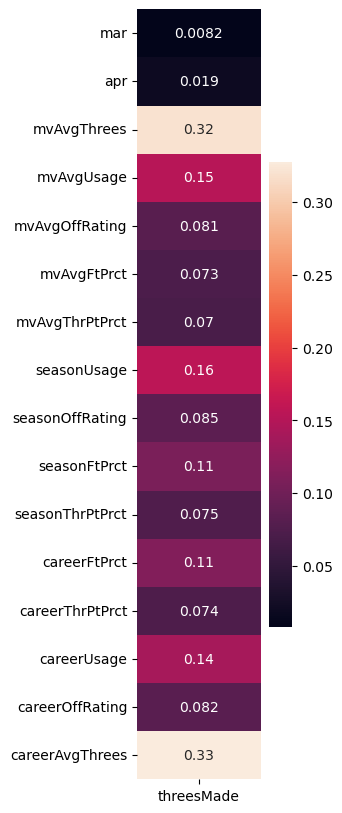

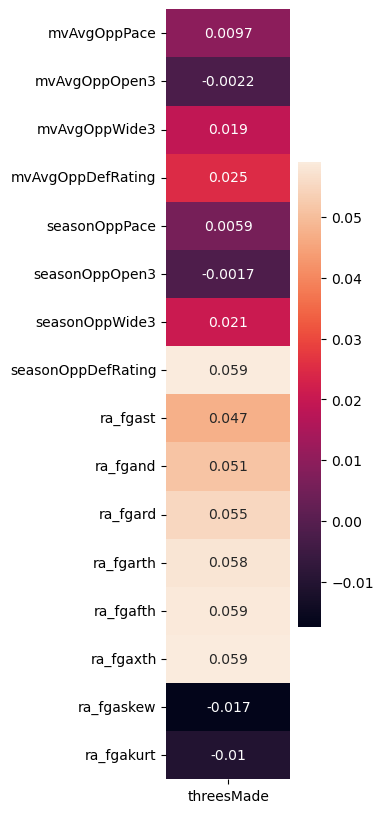

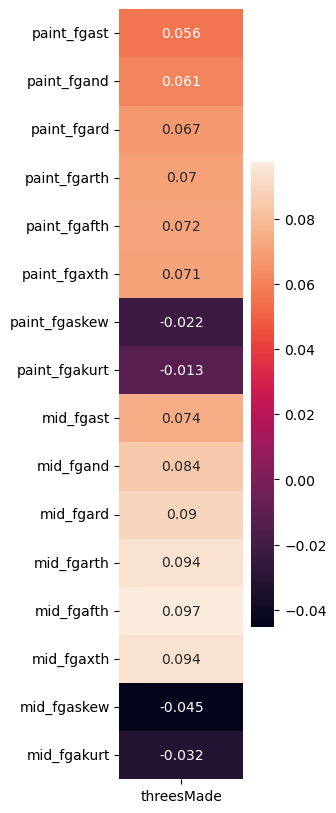

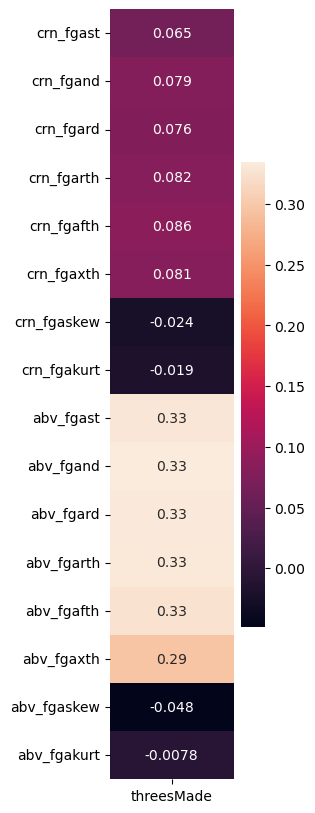

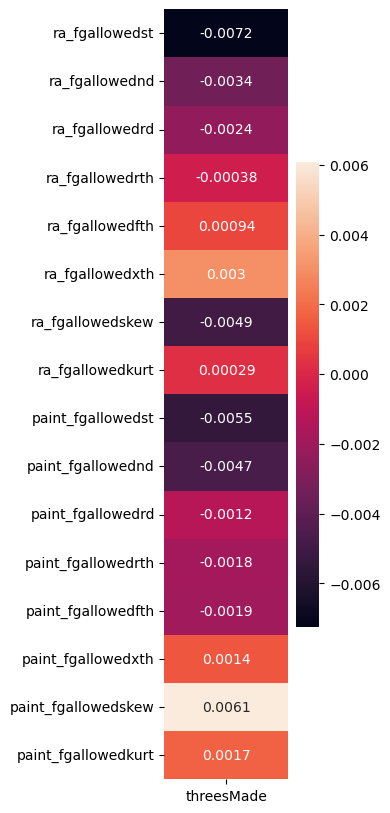

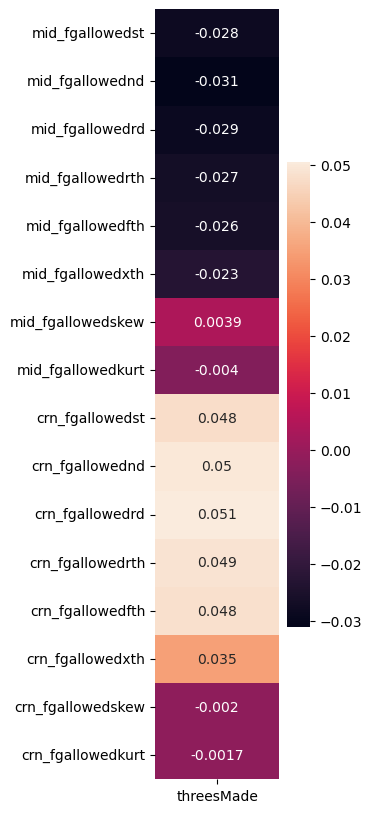

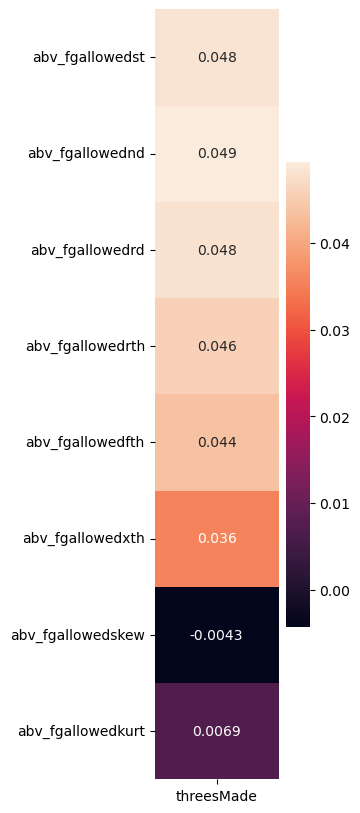

In [1097]:
for iter in range(int(len(final.columns) / 16)):
    cols = X.columns[iter*16:iter*16+16]
    plt.figure(figsize=(2,10))
    sns.heatmap(X.filter(cols).join(y).corr()[['threesMade']].drop('threesMade'),annot=True)
    plt.show()

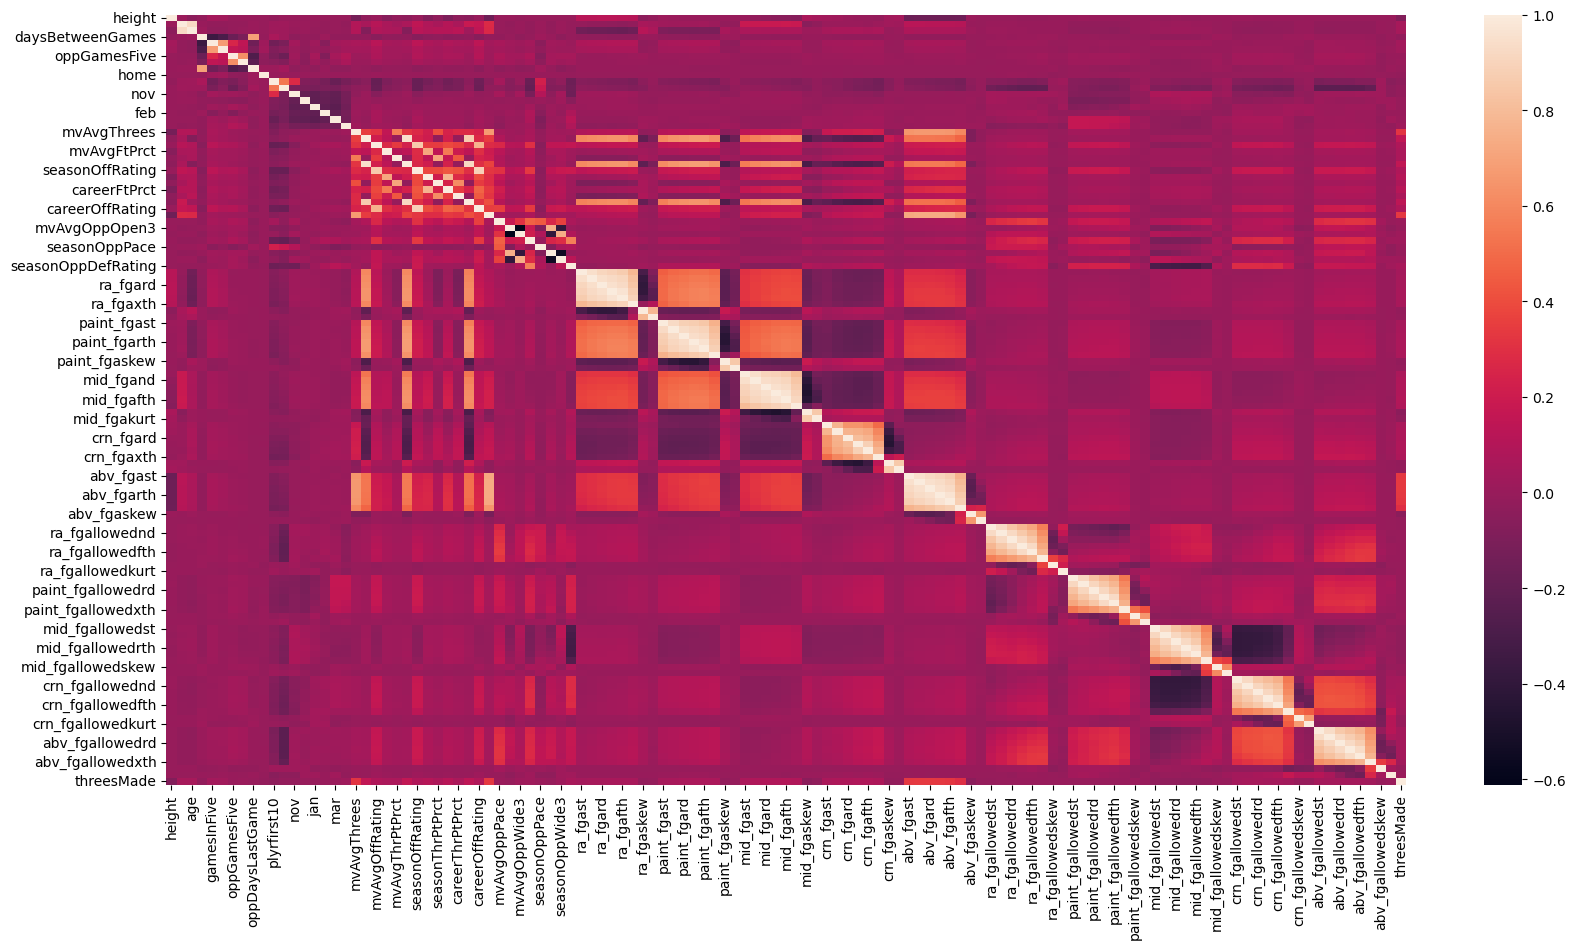

In [1098]:
plt.figure(figsize=(20,10))
sns.heatmap(X.join(y).corr())
plt.show()

In [1796]:
trainInd = data[(data.game_date < '2022-10-01')].index

In [1797]:
trainInd

Index([    0,     1,     2,     3,     4,     5,     6,     7,     8,     9,
       ...
       60446, 60447, 60448, 60449, 60450, 60451, 60452, 60453, 60454, 60455],
      dtype='int64', length=60456)

In [1798]:
testInd = data[(data.game_date > '2022-10-01') & (data.game_date < '2023-10-01')].index

In [1799]:
testInd

Index([60456, 60457, 60458, 60459, 60460, 60461, 60462, 60463, 60464, 60465,
       ...
       71857, 71858, 71859, 71860, 71861, 71862, 71863, 71864, 71865, 71866],
      dtype='int64', length=11411)

In [1793]:
valInd = data[(data.game_date > '2023-10-01')].index

In [1791]:
data

,threesMade,name,player_id,game_id,game_date,season,team,height,exp,age,...,ra_fgallowedskew,ra_fgallowedkurt,paint_fgallowedskew,paint_fgallowedkurt,mid_fgallowedskew,mid_fgallowedkurt,crn_fgallowedskew,crn_fgallowedkurt,abv_fgallowedskew,abv_fgallowedkurt
0,2,Channing Frye,101112,0021600001,2016-10-25,2016-17,CLE,84,11,33.415,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Manu Ginobili,1938,0021600003,2016-10-25,2016-17,SAS,78,17,39.217,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,Kevin Durant,201142,0021600003,2016-10-25,2016-17,GSW,83,9,28.044,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2,Kevin Love,201567,0021600001,2016-10-25,2016-17,CLE,80,8,28.104,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,Courtney Lee,201584,0021600001,2016-10-25,2016-17,NYK,77,8,31.034,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84201,2,Andrew Wiggins,203952,0022301198,2024-04-14,2023-24,GSW,79,9,28.641,...,0.345,-0.741,-0.545,0.083,0.352,1.009,0.321,-0.877,1.161,1.807
84202,1,Dario Saric,203967,0022301198,2024-04-14,2023-24,GSW,82,9,29.520,...,0.345,-0.741,-0.545,0.083,0.352,1.009,0.321,-0.877,1.161,1.807
84203,3,Bogdan Bogdanovic,203992,0022301188,2024-04-14,2023-24,ATL,77,9,31.157,...,0.102,-1.206,1.047,0.413,0.456,-0.203,0.580,-1.023,1.527,3.132
84204,1,Vasilije Micic,203995,0022301187,2024-04-14,2023-24,CHA,75,9,29.752,...,-0.450,0.495,0.867,0.151,-0.531,0.665,0.515,-0.681,0.778,0.884


In [1102]:
trainInd.shape[0] / X.shape[0]

0.6858648522446802

In [1103]:
testInd.shape[0] / X.shape[0]

0.15087719298245614

In [1104]:
valInd.shape[0] / X.shape[0]

0.16325795477286373

In [1412]:
X_train,X_test,X_val,y_train,y_test,y_val = X.loc[trainInd],X.loc[testInd],X.loc[valInd],y.loc[trainInd],y.loc[testInd],y.loc[valInd]

In [1106]:
rfc = RandomForestClassifier()
rfc.fit(X_train,y_train)

RandomForestClassifier()

In [1107]:
tProbs = rfc.predict_proba(X_test)

In [1115]:
tpDF = pd.DataFrame(tProbs)

In [1200]:
tProbs

array([[0.46, 0.23, 0.16, ..., 0.  , 0.  , 0.  ],
       [0.25, 0.28, 0.23, ..., 0.  , 0.  , 0.  ],
       [0.31, 0.24, 0.19, ..., 0.  , 0.  , 0.  ],
       ...,
       [0.1 , 0.26, 0.23, ..., 0.  , 0.  , 0.  ],
       [0.08, 0.21, 0.22, ..., 0.  , 0.  , 0.  ],
       [0.06, 0.23, 0.31, ..., 0.  , 0.  , 0.  ]])

In [1213]:
tpDF = probDf(tProbs,y_test,data[['name','game_date']],testInd)

In [1123]:
##retrain without the distributions
nonDistCols = [col for col in X.columns if re.search('st$|fth$|nd$|rd$|rth$|xth$|oct|nov|dec|jan|feb|mar|apr',col)==None]

In [1124]:
rfcNonD = RandomForestClassifier()

In [1125]:
rfcNonD.fit(X_train.filter(nonDistCols),y_train)

RandomForestClassifier()

In [1214]:
nonDProbs = rfcNonD.predict_proba(X_test.filter(nonDistCols))
nonDF = probDf(nonDProbs,y_test,data[['name','game_date']],testInd)

In [1127]:
import statsmodels as sm

In [1128]:
from sklearn.preprocessing import StandardScaler,Normalizer

In [1129]:
ss = StandardScaler()
norm = Normalizer()

In [1671]:
x_train_scale = X.loc[trainInd].filter(nonDistCols)
scaleCols = ['mvAvgThrees', 'mvAvgUsage', 'mvAvgOffRating', 'mvAvgFtPrct',
       'mvAvgThrPtPrct', 'seasonUsage', 'seasonOffRating', 'seasonFtPrct',
       'seasonThrPtPrct', 'mvAvgOppPace', 'mvAvgOppOpen3','careerFtPrct', 
       'careerOffRating', 'careerAvgThrees','careerThrPtPrct', 'careerUsage',
       'mvAvgOppWide3', 'mvAvgOppDefRating', 'seasonOppPace', 'seasonOppOpen3',
       'seasonOppWide3', 'seasonOppDefRating','height','exp','age','dabbysBetweenGames', 'gamesInFive',
       'gamesInThree', 'oppGamesFive', 'oppGamesThree', 'oppDaysLastGame']
for col in scaleCols:
    x_train_scale[col] = ss.fit_transform(x_train_scale[col].values.reshape(-1,1))
mm = sm.MNLogit(endog = y_train, exog = x_train_scale,method='bfgs')
model = mm.fit()
x_test_scale = X_test.filter(nonDistCols).copy()
for col in scaleCols:
    x_test_scale[col] = ss.fit_transform(x_test_scale[col].values.reshape(-1,1))
preds = model.predict(x_test_scale)

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['method']
  warnings.warn(msg, ValueWarning)


         Current function value: 1.719412
         Iterations: 35


/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [1672]:
data.threesMade.mean()

1.9019328075251345

In [1655]:
x_train_scale = X_train.filter(nonDistCols).copy()
scaleCols = ['mvAvgThrees', 'mvAvgUsage', 'mvAvgOffRating', 'mvAvgFtPrct',
       'mvAvgThrPtPrct', 'seasonUsage', 'seasonOffRating', 'seasonFtPrct',
       'seasonThrPtPrct', 'careerFtPrct', 'careerThrPtPrct', 'careerUsage',
       'careerOffRating', 'careerAvgThrees', 'mvAvgOppPace', 'mvAvgOppOpen3',
       'mvAvgOppWide3', 'mvAvgOppDefRating', 'seasonOppPace', 'seasonOppOpen3',
       'seasonOppWide3', 'seasonOppDefRating','height','exp','age','daysBetweenGames', 'gamesInFive',
       'gamesInThree', 'oppGamesFive', 'oppGamesThree', 'oppDaysLastGame']
for col in scaleCols:
    x_train_scale[col] = ss.fit_transform(x_train_scale[col].values.reshape(-1,1))
mm = sm.MNLogit(endog = y_train, exog = x_train_scale,method='bfgs')
model = mm.fit()
x_test_scale = X_test.filter(nonDistCols).copy()
for col in scaleCols:
    x_test_scale[col] = ss.fit_transform(x_test_scale[col].values.reshape(-1,1))
preds = model.predict(x_test_scale)

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['method']
  warnings.warn(msg, ValueWarning)


         Current function value: 1.719412
         Iterations: 35


/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [1661]:
x_train_scale.isna().sum()

height                 0
exp                    0
age                    0
daysBetweenGames       0
gamesInFive            0
gamesInThree           0
oppGamesFive           0
oppGamesThree          0
oppDaysLastGame        0
home                   0
plyrfirst10            0
mvAvgThrees            0
mvAvgUsage             0
mvAvgOffRating         0
mvAvgFtPrct            0
mvAvgThrPtPrct         0
seasonUsage            0
seasonOffRating        0
seasonFtPrct           0
seasonThrPtPrct        0
careerFtPrct           0
careerThrPtPrct        0
careerUsage            0
careerOffRating        0
careerAvgThrees        0
mvAvgOppPace           0
mvAvgOppOpen3          0
mvAvgOppWide3          0
mvAvgOppDefRating      0
seasonOppPace          0
seasonOppOpen3         0
seasonOppWide3         0
seasonOppDefRating     0
ra_fgaskew             0
ra_fgakurt             0
paint_fgaskew          0
paint_fgakurt          0
mid_fgaskew            0
mid_fgakurt            0
crn_fgaskew            0


In [1356]:
x_test_scale = X_test.filter(nonDistCols).copy()
for col in scaleCols:
    x_test_scale[col] = ss.fit_transform(x_test_scale[col].values.reshape(-1,1))
preds = model.predict(x_test_scale)

In [1369]:
model.pvalues

,0,1,2,3,4,5,6,7,8,9,10,11,12
height,0.488,0.893,0.904,0.048,0.001,0.005,0.022,0.061,0.242,0.332,0.060,0.403,0.966
exp,0.801,0.039,0.168,0.072,0.356,0.357,0.110,0.223,0.178,0.230,0.035,0.501,0.119
age,0.609,0.032,0.096,0.157,0.490,0.264,0.065,0.080,0.146,0.157,0.019,0.325,0.091
daysBetweenGames,0.689,0.245,0.496,0.127,0.293,0.579,0.271,0.294,0.334,0.278,0.682,0.829,0.503
gamesInFive,0.013,0.001,0.765,0.271,0.121,0.128,0.982,0.343,0.173,0.836,0.728,0.580,0.985
gamesInThree,0.922,0.804,0.070,0.066,0.404,0.469,0.800,0.449,0.284,0.428,0.296,0.341,0.506
oppGamesFive,0.057,0.009,0.016,0.680,0.064,0.383,0.014,0.698,0.504,0.456,0.386,0.862,0.899
oppGamesThree,0.618,0.397,0.400,0.977,0.079,0.807,0.257,0.317,0.730,0.555,0.683,0.976,0.901
oppDaysLastGame,0.280,0.263,0.720,0.539,0.666,0.235,0.795,0.313,0.022,0.296,0.572,0.761,0.400
home,0.466,0.307,0.104,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.069,0.008


In [1145]:
import seaborn as sns
import matplotlib.pyplot as plt

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='probExact', ylabel='Count'>

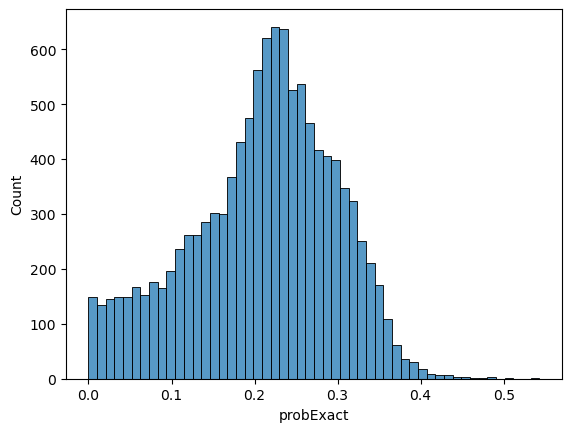

In [1215]:
sns.histplot(lgDF.probExact)

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


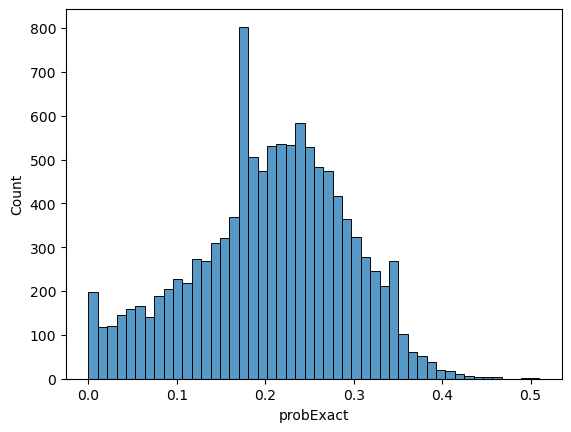

In [1216]:
sns.histplot(tpDF.probExact)
plt.show()

In [1217]:
nonDF = probDf(nonDProbs,y_test,data[['name','game_date']],testInd)

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


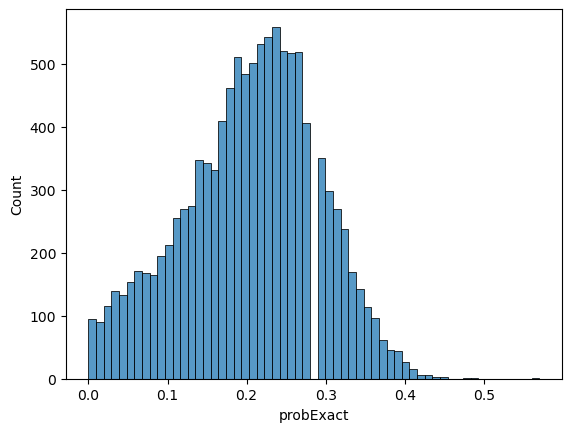

In [1218]:
sns.histplot(nonDF.probExact)
plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='probOccur+', ylabel='Count'>

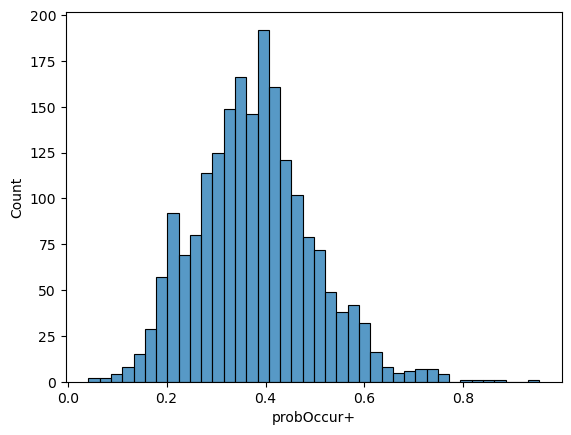

In [1223]:
sns.histplot(lgDF[np.where(lgDF.actuals==lgDF.careerAvgThrees.add(1.5).astype(int),True,False)]['probOccur+'])

In [1237]:
nonDF[nonDF.actuals - nonDF.careerAvgThrees>=.75].sort_values(by='probOccur+',ascending=False).head(50)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,probOccur+,probExact,actuals,name,game_date,careerAvgThrees
7601,0.170,0.350,0.240,0.170,0.050,0.000,0.000,0.020,0.000,0.000,0.000,0.000,0.000,0.000,0.830,0.350,1,Jose Alvarado,2022-10-19,0.000
7658,0.230,0.570,0.100,0.080,0.020,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.770,0.570,1,Ish Wainright,2022-11-20,0.000
7741,0.240,0.340,0.220,0.090,0.060,0.020,0.010,0.020,0.000,0.000,0.000,0.000,0.000,0.000,0.760,0.340,1,Jaden Hardy,2022-12-29,0.143
5562,0.270,0.400,0.150,0.120,0.040,0.010,0.000,0.010,0.000,0.000,0.000,0.000,0.000,0.000,0.730,0.400,1,Killian Hayes,2022-10-26,0.000
6154,0.310,0.260,0.240,0.140,0.010,0.040,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.690,0.260,1,R.J. Hampton,2022-10-19,0.000
3354,0.310,0.480,0.110,0.100,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.690,0.480,1,Caleb Martin,2022-10-19,0.000
5939,0.320,0.360,0.130,0.120,0.050,0.020,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.680,0.360,1,Aaron Nesmith,2022-10-19,0.000
5861,0.330,0.380,0.170,0.100,0.020,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.670,0.380,1,Patrick Williams,2022-10-21,0.000
6248,0.380,0.330,0.100,0.160,0.010,0.010,0.010,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.620,0.330,1,Isaiah Stewart,2022-10-19,0.000
7266,0.380,0.350,0.150,0.080,0.020,0.020,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.620,0.350,1,Sandro Mamukelashvili,2022-11-11,0.000


In [1233]:
lgDF[lgDF.actuals - lgDF.careerAvgThrees>=1.9].sort_values(by='probOccur+',ascending=False).head(50)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,probOccur+,probExact,actuals,name,game_date,careerAvgThrees
664,0.057,0.060,0.061,0.044,0.047,0.025,0.018,0.018,0.005,0.016,0.014,0.032,0.598,0.005,0.732,0.025,5,Norman Powell,2022-11-19,1.882
2761,0.060,0.073,0.107,0.142,0.137,0.104,0.076,0.100,0.063,0.032,0.081,0.018,0.000,0.005,0.617,0.137,4,Mikal Bridges,2023-03-29,1.632
4676,0.038,0.054,0.075,0.098,0.119,0.159,0.105,0.071,0.099,0.059,0.018,0.090,0.014,0.001,0.616,0.159,5,Tyler Herro,2023-01-02,2.448
3616,0.018,0.040,0.074,0.115,0.183,0.167,0.126,0.124,0.061,0.035,0.036,0.019,0.000,0.000,0.569,0.167,5,Anfernee Simons,2022-11-15,2.222
4700,0.037,0.059,0.083,0.119,0.157,0.114,0.078,0.034,0.090,0.054,0.100,0.012,0.052,0.011,0.545,0.114,5,Tyler Herro,2023-03-10,2.480
5989,0.117,0.128,0.109,0.102,0.098,0.060,0.097,0.052,0.068,0.082,0.015,0.042,0.001,0.030,0.544,0.098,4,Aaron Nesmith,2023-02-15,1.540
10415,0.024,0.050,0.082,0.111,0.100,0.101,0.148,0.100,0.077,0.129,0.039,0.037,0.000,0.001,0.532,0.148,6,Tim Hardaway Jr.,2023-02-23,2.517
11267,0.077,0.088,0.091,0.093,0.080,0.071,0.071,0.056,0.036,0.051,0.069,0.022,0.193,0.001,0.500,0.071,6,LeBron James,2022-11-30,2.105
5988,0.144,0.133,0.123,0.117,0.106,0.082,0.097,0.070,0.067,0.026,0.010,0.015,0.000,0.009,0.483,0.106,4,Aaron Nesmith,2023-02-13,1.490
634,0.044,0.075,0.115,0.155,0.140,0.120,0.140,0.058,0.074,0.037,0.012,0.025,0.002,0.002,0.471,0.120,5,Terry Rozier,2023-02-13,2.460


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='probExact', ylabel='Count'>

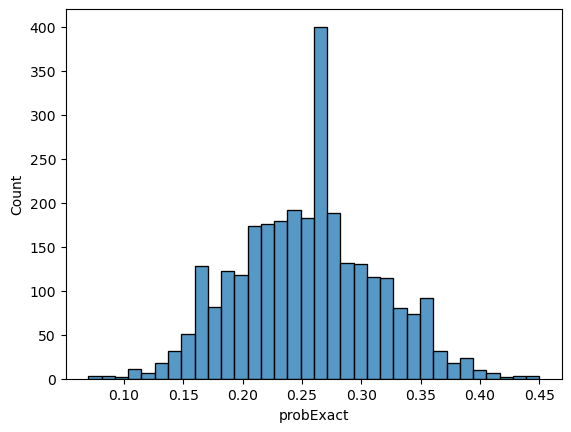

In [1221]:
sns.histplot(nonDF[np.where(nonDF.actuals==nonDF.careerAvgThrees.add(.5).astype(int),True,False)].probExact)

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='probExact', ylabel='Count'>

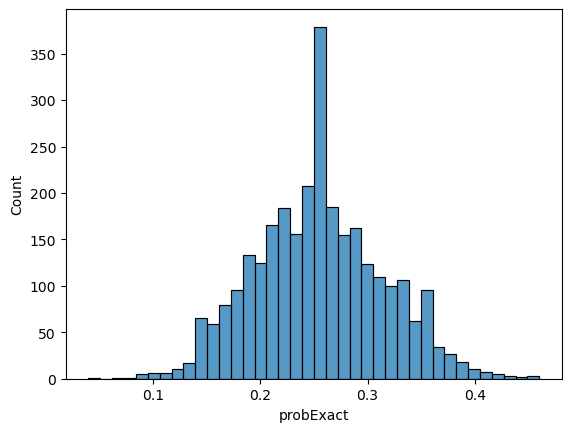

In [1222]:
sns.histplot(tpDF[np.where(tpDF.actuals==tpDF.careerAvgThrees.add(.5).astype(int),True,False)].probExact)

In [1353]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:             threesMade   R-squared (uncentered):                   0.020
Model:                            OLS   Adj. R-squared (uncentered):              0.020
Method:                 Least Squares   F-statistic:                              1533.
Date:                Sun, 13 Oct 2024   Prob (F-statistic):                        0.00
Time:                        20:24:09   Log-Likelihood:                     -1.7173e+05
No. Observations:               73668   AIC:                                  3.435e+05
Df Residuals:                   73667   BIC:                                  3.435e+05
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
abv_fgallowedkurt     0.2281      0.006     39.150      0.000       0.217       0.240
==============================================================================
Omnibus:                    10512.122   Durbin-Watson:                   0.884
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            17319.135
Skew:                           0.973   Prob(JB):                         0.00
Kurtosis:                       4.363   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [1382]:
##Capped shots made at 8
rfCap = RandomForestClassifier()

In [1416]:
rfCap.fit(x__train_scale,[8 if x>= 8 else x for x in y_train])
capProbs = rfCap.predict_proba(X_test)

In [1479]:
capDF = probDf(capProbs,pd.Series([8 if x>=8 else x for x in y_test]),data[['name','game_date','careerAvgThrees']],testInd)

In [1759]:
def probDf(probs,y,addDf,ind):
    df = pd.DataFrame(probs,index = ind)
    df['probOccur+'] =  [sum(probs[act:]) if act != 0 else probs[0] for probs,act in zip(probs,y.values)]
    df['probExact'] = [probs[act] for probs,act in zip(df.values,y.values)]
    df['actuals'] = y.values
    df = df.join(addDf.loc[ind][['name','game_date']]).reset_index(drop=True)
    return df

In [ ]:
capDF.drop

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='probOccur+', ylabel='Count'>

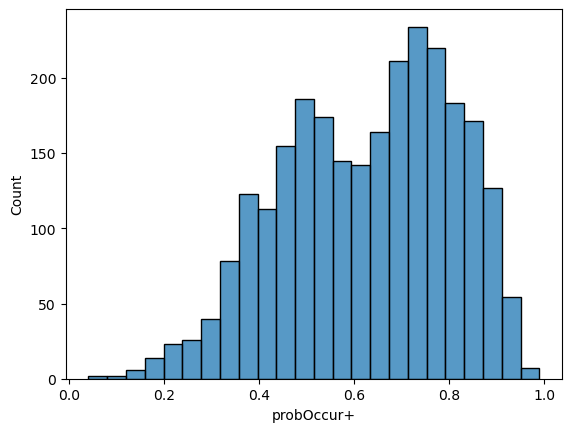

In [1487]:
pltdf = capDF.dropna()
sns.histplot(pltdf[np.where(pltdf.actuals==pltdf.careerAvgThrees.add(.5).astype(int),True,False)]['probOccur+'])

In [1488]:
pltdf[np.where(pltdf.actuals==pltdf.careerAvgThrees.add(.5).astype(int),True,False)]['probOccur+'].value_counts()

probOccur+
0.550    50
0.510    47
0.500    44
0.520    43
0.770    43
         ..
0.960     1
0.150     1
0.380     1
0.850     1
0.860     1
Name: count, Length: 234, dtype: int64

In [1507]:
pltdf.columns

Index([          'index',                 0,                 1,
                       2,                 3,                 4,
                       5,                 6,                 7,
                       8,      'probOccur+',       'probExact',
               'actuals',            'name',       'game_date',
       'careerAvgThrees'],
      dtype='object')

In [1532]:
nonDF[[0,1,2,3,4,5,6,7,8,9,10,11,12,13,]].mean()

0    0.192
1    0.254
2    0.226
3    0.156
4    0.091
5    0.043
6    0.023
7    0.009
8    0.004
9    0.001
10   0.001
11   0.000
12   0.000
13   0.000
dtype: float64

In [1533]:
lgDF[[0,1,2,3,4,5,6,7,8,9,10,11,12,13,]].mean()

0    0.204
1    0.262
2    0.218
3    0.152
4    0.085
5    0.040
6    0.022
7    0.009
8    0.004
9    0.002
10   0.001
11   0.001
12   0.001
13   0.000
dtype: float64

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: ylabel='Count'>

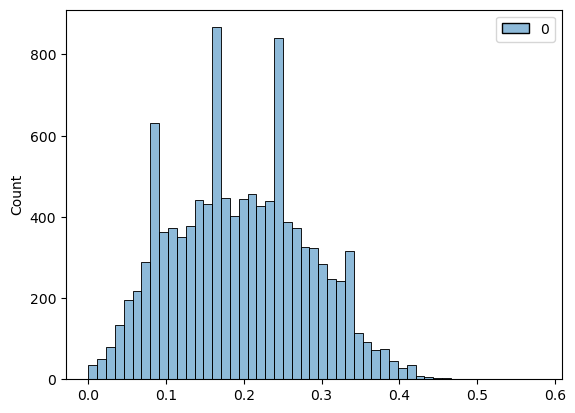

In [1516]:
sns.histplot(pltdf[[0]])

In [1531]:
plSht = pd.read_sql('''select abv_fga,abv_fgm,lc_fga,lc_fgm,rc_fga,rc_fgm,player_id,name,game_date,usagePercentage

                    from plyrLogs
                    JOIN 
                        (SELECT RANK() OVER(PARTITION BY team_id,season ORDER BY game_date)

                    '''

,threesMade,name,player_id,game_id,game_date,season,team,height,exp,age,...,crn_fgallowedskew,crn_fgallowedkurt,abv_fgallowedst,abv_fgallowednd,abv_fgallowedrd,abv_fgallowedrth,abv_fgallowedfth,abv_fgallowedxth,abv_fgallowedskew,abv_fgallowedkurt
0,0,Chris Paul,101108,0021700002,2017-10-17,2017-18,HOU,72,12,32.444,...,0.760,0.403,16.500,18.500,20.000,22.000,24.500,30.000,0.548,0.048
1,1,Terry Rozier,1626179,0021700001,2017-10-17,2017-18,BOS,73,2,23.581,...,-0.082,-1.448,18.000,20.000,23.000,23.500,28.000,34.000,0.377,0.048
2,2,Jaylen Brown,1627759,0021700001,2017-10-17,2017-18,BOS,78,1,20.975,...,-0.082,-1.448,18.000,20.000,23.000,23.500,28.000,34.000,0.377,0.048
3,1,Jayson Tatum,1628369,0021700001,2017-10-17,2017-18,BOS,80,0,19.619,...,-0.082,-1.448,18.000,20.000,23.000,23.500,28.000,34.000,0.377,0.048
4,4,P.J. Tucker,200782,0021700002,2017-10-17,2017-18,HOU,77,11,32.446,...,0.760,0.403,16.500,18.500,20.000,22.000,24.500,30.000,0.548,0.048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75688,2,Andrew Wiggins,203952,0022301198,2024-04-14,2023-24,GSW,79,9,28.641,...,0.321,-0.877,25.500,27.000,28.000,30.000,33.000,42.000,1.161,1.807
75689,1,Dario Saric,203967,0022301198,2024-04-14,2023-24,GSW,82,9,29.520,...,0.321,-0.877,25.500,27.000,28.000,30.000,33.000,42.000,1.161,1.807
75690,3,Bogdan Bogdanovic,203992,0022301188,2024-04-14,2023-24,ATL,77,9,31.157,...,0.580,-1.023,16.500,18.000,20.000,21.500,22.500,34.000,1.527,3.132
75691,1,Vasilije Micic,203995,0022301187,2024-04-14,2023-24,CHA,75,9,29.752,...,0.515,-0.681,23.000,23.500,25.000,26.500,29.000,35.000,0.778,0.884


In [1540]:
rlCh = pd.read_sql(''' SELECT name, player_id, season, (coalesce(lc_fga,0) + coalesce(rc_fga,0)) crn_fga, abv_fga, game_date
                from pgames
                WHERE player_id||season in 
                    (SELECT player_id||season
                    FROM pgames 

                    group by player_id,season

                    HAVING AVG(coalesce(lc_fga,0) + coalesce(rc_fga,0) + coalesce(abv_fga,0)) >= 3
                    and max(plyrGameCt) >= 16
                    
                    )
                ''',nba.conn)

In [1601]:
shtQuantQ = '''SELECT game_date,
  MAX(CASE WHEN abv_tile = 1 THEN abv_fga END) AS abv_tile1,
  MAX(CASE WHEN abv_tile = 2 THEN abv_fga END) AS abv_tile2,
  MAX(CASE WHEN abv_tile = 3 THEN abv_fga END) AS abv_tile3,
  MAX(CASE WHEN abv_tile = 4 THEN abv_fga END) AS abv_tile4,
  MAX(CASE WHEN abv_tile = 5 THEN abv_fga END) AS abv_tile5,
  MAX(CASE WHEN abv_tile = 6 THEN abv_fga END) AS abv_tile6,
  MAX(CASE WHEN crn_tile = 1 THEN crn_fga END) AS crn_tile1,
  MAX(CASE WHEN crn_tile = 2 THEN crn_fga END) AS crn_tile2,
  MAX(CASE WHEN crn_tile = 3 THEN crn_fga END) AS crn_tile3,
  MAX(CASE WHEN crn_tile = 4 THEN crn_fga END) AS crn_tile4,
  MAX(CASE WHEN crn_tile = 5 THEN crn_fga END) AS crn_tile5,
  MAX(CASE WHEN crn_tile = 6 THEN crn_fga END) AS crn_tile6
FROM (
  SELECT game_date,abv_fga, NTILE(6) OVER (ORDER BY game_date) AS abv_tile,
         (coalesce(lc_fga,0) + coalesce(rc_fga,0)) crn_fga, NTILE(6) OVER (ORDER BY game_date) AS crn_tile
  FROM plyrLogs
  WHERE player_id||game_date in 
                    (SELECT player_id||game_date
                    FROM pgames 

                    group by player_id,season

                    HAVING AVG(coalesce(lc_fga,0) + coalesce(rc_fga,0) + coalesce(abv_fga,0)) >= 3
                    and max(plyrGameCt) >= 16
                    
                    )
) AS q
GROUP BY game_date,abv_tile,crn_tile;
'''

In [1599]:
tileq = '''  SELECT game_date,abv_fga, NTILE(6) OVER (ORDER BY game_date) AS abv_tile,
         (coalesce(lc_fga,0) + coalesce(rc_fga,0)) crn_fga, NTILE(6) OVER (ORDER BY game_date) AS crn_tile
  FROM plyrLogs
  WHERE player_id||game_date in 
                    (SELECT player_id||game_date
                    FROM pgames 

                    group by player_id,season

                    HAVING AVG(coalesce(lc_fga,0) + coalesce(rc_fga,0) + coalesce(abv_fga,0)) >= 3
                    and max(plyrGameCt) >= 16
                    
                    )'''
tiledf = pd.read_sql(tileq,nba.conn)

In [1612]:
pd.read_sql('''select distinct game_date from pgames
  WHERE player_id||season in 
                    (SELECT player_id||season
                    FROM pgames 

                    group by player_id,season

                    HAVING AVG(coalesce(lc_fga,0) + coalesce(rc_fga,0) + coalesce(abv_fga,0)) >= 3
                    and max(plyrGameCt) >= 16
                    
                    )
                    order by game_date''',nba.conn)

,game_date
0,2016-10-25
1,2016-10-26
2,2016-10-27
3,2016-10-28
4,2016-10-29
...,...
1272,2024-04-09
1273,2024-04-10
1274,2024-04-11
1275,2024-04-12


In [1613]:
pd.read_sql(shtQuantQ,nba.conn)

,game_date,abv_tile1,abv_tile2,abv_tile3,abv_tile4,abv_tile5,abv_tile6,crn_tile1,crn_tile2,crn_tile3,crn_tile4,crn_tile5,crn_tile6
0,2017-01-18,3.000,NaN,NaN,NaN,NaN,NaN,1.000,NaN,NaN,NaN,NaN,NaN
1,2017-01-27,6.000,NaN,NaN,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN
2,2017-02-03,2.000,NaN,NaN,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN
3,2017-02-08,1.000,NaN,NaN,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN
4,2017-03-03,2.000,NaN,NaN,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,2024-04-09,NaN,NaN,NaN,NaN,NaN,13.000,NaN,NaN,NaN,NaN,NaN,0.000
240,2024-04-10,NaN,NaN,NaN,NaN,NaN,13.000,NaN,NaN,NaN,NaN,NaN,2.000
241,2024-04-11,NaN,NaN,NaN,NaN,NaN,10.000,NaN,NaN,NaN,NaN,NaN,3.000
242,2024-04-12,NaN,NaN,NaN,NaN,NaN,13.000,NaN,NaN,NaN,NaN,NaN,3.000


In [1571]:
#need to get the frame into game dates
quants = ([1/6,1/3,.5,2/3,5/6,1],['st','nd','rd','rth','fth','xth'])
for loc in ['crn_fga','abv_fga']:
    temp = [rlCh.groupby(['player_id'])[loc].rolling(41,closed='left',min_periods=10).quantile(q,'midpoint')for q in quants[0]]
    pdf = pd.DataFrame(temp,index=['{}{}'.format(loc,q) for q in quants[1]]).T

In [1572]:
teamPdf = pd.DataFrame(teamTemp,index=['abv_fga{}'.format(q) for q in quants[1]]).T

In [1573]:
teamPdf

abv_fgast  abv_fgand  abv_fgard  abv_fgarth  abv_fgafth  \
game_date                                                                   
2016-10-25 721          NaN        NaN        NaN         NaN         NaN   
           44253        NaN        NaN        NaN         NaN         NaN   
           45814        NaN        NaN        NaN         NaN         NaN   
           48644        NaN        NaN        NaN         NaN         NaN   
           50825        NaN        NaN        NaN         NaN         NaN   
...                     ...        ...        ...         ...         ...   
2024-04-14 79758      2.000      2.000      4.000       4.000       6.000   
           80525      2.000      2.000      4.000       4.000       6.000   
           80962      2.000      2.000      4.000       4.000       6.000   
           80990      2.000      2.000      4.000       4.000       5.000   
           83097      2.000      2.000      4.000       4.000       5.000   

                  abv_fgaxth  
game_date                     
2016-10-25 721           NaN  
           44253         NaN  
           45814         NaN  
           48644         NaN  
           50825         NaN  
...                      ...  
2024-04-14 79758      10.000  
           80525      10.000  
           80962      10.000  
           80990      10.000  
           83097      10.000  

[84206 rows x 6 columns]

In [1582]:
#need to get the frame by date

temp,index=['{}{}'.format(loc,q) for q in quants[1]]).T

game_date
2016-10-25    8.000
2016-10-26   10.000
2016-10-27    7.000
2016-10-28    9.000
2016-10-29   10.000
              ...  
2024-04-09   16.000
2024-04-10   13.000
2024-04-11   14.000
2024-04-12   13.000
2024-04-14   14.000
Name: abv_fga, Length: 1277, dtype: float64

In [ ]:
nonDistCols

In [1670]:
x_train_scale = X.loc[trainInd].filter(nonDistCols)
scaleCols = ['mvAvgThrees', 'mvAvgUsage', 'mvAvgOffRating', 'mvAvgFtPrct',
       'mvAvgThrPtPrct', 'seasonUsage', 'seasonOffRating', 'seasonFtPrct',
       'seasonThrPtPrct', 'mvAvgOppPace', 'mvAvgOppOpen3',
       'mvAvgOppWide3', 'mvAvgOppDefRating', 'seasonOppPace', 'seasonOppOpen3',
       'seasonOppWide3', 'seasonOppDefRating','height','exp','age','daysBetweenGames', 'gamesInFive',
       'gamesInThree', 'oppGamesFive', 'oppGamesThree', 'oppDaysLastGame']
for col in scaleCols:
    x_train_scale[col] = ss.fit_transform(x_train_scale[col].values.reshape(-1,1))
mm = sm.MNLogit(endog = y_train, exog = x_train_scale,method='bfgs')
model = mm.fit()
x_test_scale = X_test.filter(nonDistCols).copy()
for col in scaleCols:
    x_test_scale[col] = ss.fit_transform(x_test_scale[col].values.reshape(-1,1))
preds = model.predict(x_test_scale)

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['method']
  warnings.warn(msg, ValueWarning)
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:3025: RuntimeWarning: overflow encountered in exp
  eXB = np.column_stack((np.ones(len(X)), np.exp(X)))
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:3026: RuntimeWarning: invalid value encountered in divide
  return eXB/eXB.sum(1)[:,None]


Optimization terminated successfully.
         Current function value: nan
         Iterations 16


In [180]:
data = nba.threeData()
y = data.threesMade


DatabaseError: Execution failed on sql '
-- This primiarily calculates rolling fields and game information for the days game to be used in the model.
-- Need to check game info in the future to see if we can preload a schedule
-- Shot attempts will be done in seperate queries as they are going through a python function for the rolling information
-- Future updates - how to incorporate inactives, can do a rolling value but would like more information on who is out and impact

SELECT 
--y
threesMade,

--identifiers
name, player_id, game_id, game_date, season, team,

--demo data
height, exp, age,

--shot locations, will have percentiles done in pandas
ra_fga, paint_fga, mid_fga, (coalesce(lc_fga,0) + coalesce(rc_fga,0)) crn_fga, abv_fga,

--games info
daysBetweenGames, gamesInFive, gamesInThree, oppGamesFive, OppGamesThree, oppDaysLastGame, home, plyrGameCt, tmGameCt,
CASE WHEN plyrGameCt<= 10 THEN 1 ELSE 0 END 

--roling offensive (5 games and season) metrics 

AVG(threesMade) OVER (PART

In [1817]:
model = pd.read_pickle('data/model/thrLogit.pkl')
X = data.filter(model.params.index)
X = nba.scaleData(X)
preds = model.predict(X)
df = probDf(preds.values,y.loc[valInd],data[['name','game_date']],valInd)
c = [12,11,10,9,8,7,6,5,4,3,2,1,0]
pd.DataFrame(np.array([nba.convertPercentToOdds(v) for r in day[c].cumsum(axis=1).values for v in r]).reshape(df[c].shape),columns=c)

In [1925]:
#need to read in bet history
bets = pd.read_csv('data/3bets.csv')

In [1939]:
thrBets = bets[bets.tags.str.strip() == '3play']

In [1942]:
thrBets

,bet_id,sportsbook,type,status,odds,closing_line,ev,amount,profit,time_placed,time_settled,bet_info,tags,sports,leagues
1861,O/0586450/0001060,Fanduel Sportsbook,parlay,SETTLED_LOSS,58.590,45.960,0.275,1.500,-1.500,04/28/2024 12:22:23 GMT,04/28/2024 20:02:22 GMT,Josh Hart 3+ Made Threes New York Knicks @ Phi...,3play,Basketball,NBA
1957,O/0586450/0001010,Fanduel Sportsbook,parlay,SETTLED_LOSS,4.680,5.030,-0.070,2.000,0.000,04/22/2024 19:42:30 GMT,04/23/2024 04:46:03 GMT,Evan Mobley 1+ Made Threes Orlando Magic @ Cle...,3play,Basketball,NBA
1958,O/0586450/0001008,Fanduel Sportsbook,parlay,SETTLED_LOSS,5.040,5.990,-0.159,2.000,0.000,04/22/2024 19:41:21 GMT,04/23/2024 04:46:03 GMT,Josh Hart 2+ Made Threes Philadelphia 76ers @ ...,3play,Basketball,NBA
1969,O/0586450/0001009,Fanduel Sportsbook,parlay,SETTLED_WIN,4.100,5.200,-0.211,2.000,6.200,04/22/2024 19:42:03 GMT,04/23/2024 00:28:06 GMT,Evan Mobley 1+ Made Threes Orlando Magic @ Cle...,3play,Basketball,NBA
2101,O/0586450/0000954,Fanduel Sportsbook,parlay,SETTLED_LOSS,80.080,44.660,0.793,0.750,-0.750,04/14/2024 10:19:05 GMT,04/14/2024 19:27:31 GMT,Nikola Jovic 3+ Made Threes Toronto Raptors @ ...,3play,Basketball,NBA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4124,O/0586450/0000117,Fanduel Sportsbook,parlay,SETTLED_LOSS,8.900,8.450,0.053,0.250,-0.250,12/15/2023 19:22:17 GMT,12/16/2023 02:36:28 GMT,Buddy Hield Over 3.5 Buddy Hield - Alt Threes ...,3play,Basketball,NBA
4131,O/0586450/0000113,Fanduel Sportsbook,parlay,SETTLED_LOSS,25.400,27.460,-0.075,1.500,-1.500,12/15/2023 00:22:59 GMT,12/15/2023 04:32:23 GMT,Michael Porter Jr. Over 3.5 Michael Porter Jr....,3play,Basketball,NBA
4140,O/0586450/0000109,Fanduel Sportsbook,parlay,SETTLED_LOSS,23.030,NaN,NaN,1.500,-1.500,12/14/2023 15:32:59 GMT,12/15/2023 03:00:02 GMT,Jaylen Brown 4+ Made Threes Cleveland Cavalier...,3play,Basketball,NBA
4164,O/0586450/0000101,Fanduel Sportsbook,parlay,SETTLED_LOSS,31.350,NaN,NaN,0.500,-0.500,12/13/2023 00:53:27 GMT,12/13/2023 03:37:28 GMT,Michael Porter Jr. 5+ Made Threes Denver Nugge...,3play,Basketball,NBA


In [7]:
data = nba.threeData()

In [8]:
nba.showTables

,type,name,tbl_name,rootpage,sql
0,table,rosters,rosters,4,"CREATE TABLE rosters(\n teamId TEXT,\n s..."
1,table,players,players,2,"CREATE TABLE players(\n player_id TEXT,..."
2,table,teams,teams,6,"CREATE TABLE teams(\n team_id TEXT,\n te..."
3,table,plyrLogs,plyrLogs,123,"CREATE TABLE plyrLogs (player_id TEXT,\nteam_i..."
4,view,team_game,team_game,0,"CREATE VIEW team_game as \nSELECT season, game..."
5,table,shotsAllowed,shotsAllowed,582,"CREATE TABLE shotsAllowed (team_id TEXT,\ngame..."
6,view,team_def,team_def,0,"CREATE VIEW team_def AS\nselect \nseason, subs..."
7,view,pgames,pgames,0,CREATE VIEW pgames AS\nSELECT \n--identifiying...
8,table,teamLog,teamLog,7,"CREATE TABLE teamLog(\n game_id TEXT,\n..."


In [9]:
pd.read_sql('select * from rosters',nba.conn)

,teamId,seasonYear,playerId,startDate,endDate
0,1610612737,2023-24,201988,2023-11-25,2024-02-07
1,1610612737,2023-24,202083,2023-11-11,2024-04-09
2,1610612737,2023-24,203991,2023-10-25,2024-04-12
3,1610612737,2023-24,203992,2023-10-25,2024-04-14
4,1610612737,2023-24,1627749,2023-10-25,2024-04-14
...,...,...,...,...,...
4420,1610612766,2017-18,1626203,2017-10-18,2018-03-31
4421,1610612766,2017-18,1627779,2017-10-25,2018-04-10
4422,1610612766,2017-18,1628370,2017-10-18,2018-04-10
4423,1610612766,2017-18,1628407,2017-10-18,2018-03-31


In [14]:
nba.threeData()

,threesMade,name,player_id,game_id,game_date,season,team,height,exp,age,...,ra_fgallowedskew,ra_fgallowedkurt,paint_fgallowedskew,paint_fgallowedkurt,mid_fgallowedskew,mid_fgallowedkurt,crn_fgallowedskew,crn_fgallowedkurt,abv_fgallowedskew,abv_fgallowedkurt
0,2,Channing Frye,101112,0021600001,2016-10-25,2016-17,CLE,84,11,33.415,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Manu Ginobili,1938,0021600003,2016-10-25,2016-17,SAS,78,17,39.217,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,Kevin Durant,201142,0021600003,2016-10-25,2016-17,GSW,83,9,28.044,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2,Kevin Love,201567,0021600001,2016-10-25,2016-17,CLE,80,8,28.104,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,Courtney Lee,201584,0021600001,2016-10-25,2016-17,NYK,77,8,31.034,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84201,2,Andrew Wiggins,203952,0022301198,2024-04-14,2023-24,GSW,79,9,28.641,...,0.227,-0.749,-0.416,-0.001,0.337,1.244,0.309,-0.711,0.997,1.449
84202,1,Dario Saric,203967,0022301198,2024-04-14,2023-24,GSW,82,9,29.520,...,0.227,-0.749,-0.416,-0.001,0.337,1.244,0.309,-0.711,0.997,1.449
84203,3,Bogdan Bogdanovic,203992,0022301188,2024-04-14,2023-24,ATL,77,9,31.157,...,0.044,-1.113,0.926,0.273,0.535,0.004,0.484,-1.016,1.218,1.789
84204,1,Vasilije Micic,203995,0022301187,2024-04-14,2023-24,CHA,75,9,29.752,...,-0.552,0.668,0.972,0.358,-0.643,0.785,0.342,-0.921,0.664,0.807


In [16]:
import nba_api

In [18]:
nba_api.stats.endpoints.

'nba_api'

In [73]:
import requests
r = requests.get("http://data.nba.com/data/10s/v2015/json/mobile_teams/nba/2024/league/00_full_schedule.json")
r.json()

{'lscd': [{'mscd': {'mon': 'January',
    'g': [{'gid': '0022400455',
      'gcode': '20250101/ORLDET',
      'seri': '',
      'is': 1,
      'gdte': '2025-01-01',
      'htm': '2025-01-01T19:00:00',
      'vtm': '2025-01-01T19:00:00',
      'etm': '2025-01-01T19:00:00',
      'an': 'Little Caesars Arena',
      'ac': 'Detroit',
      'as': 'MI',
      'st': '1',
      'stt': '7:00 pm ET',
      'bd': {'b': [{'seq': 1,
         'broadcasterId': 1188,
         'disp': '97.1 FM The Ticket',
         'scope': 'home',
         'type': 'radio',
         'lan': 'English',
         'url': None},
        {'seq': 2,
         'broadcasterId': 1000339,
         'disp': 'Bally Sports DET',
         'scope': 'home',
         'type': 'tv',
         'lan': 'English',
         'url': None},
        {'seq': 3,
         'broadcasterId': 1000353,
         'disp': 'Bally Sports Florida',
         'scope': 'away',
         'type': 'tv',
         'lan': 'English',
         'url': None},
        {'seq': 4,


,game_date,game_id,team_id,home
0,2025-01-01,0022400455,1610612765,1
1,2025-01-01,0022400456,1610612764,1
2,2025-01-01,0022400457,1610612748,1
3,2025-01-01,0022400458,1610612752,1
4,2025-01-01,0022400459,1610612761,1
...,...,...,...,...
2395,2024-12-31,0022400450,1610612749,0
2396,2024-12-31,0022400451,1610612746,0
2397,2024-12-31,0022400452,1610612750,0
2398,2024-12-31,0022400453,1610612763,0


In [93]:
pi = nba_api.stats.endpoints.PlayerIndex().get_data_frames()[0]

In [102]:
f = pi[['TEAM_ID']]
f['seasonYear'] = '2024-25'
f['playerId'] = pi.PERSON_ID
f['startDate'] = '2024-10-22'
f['endDate'] = None

In [197]:
[(idx,x) for idx,x in enumerate(pd.read_sql('select * from teamLog limit 1',nba.conn).columns)]

[(0, 'game_id'),
 (1, 'game_date'),
 (2, 'team_id'),
 (3, 'inactive'),
 (4, 'count_inactive'),
 (5, 'assist_pct'),
 (6, 'off_rate'),
 (7, 'def_rate'),
 (8, 'pace'),
 (9, 'possessions'),
 (10, 'off_reb_pct'),
 (11, 'def_reb_pct'),
 (12, 'second_pts'),
 (13, 'fastb_pts'),
 (14, 'tm_to'),
 (15, 'to_pts'),
 (16, 'home'),
 (17, 'q1_pts'),
 (18, 'q2_pts'),
 (19, 'q3_pts'),
 (20, 'q4_pts'),
 (21, 'ot1_pts'),
 (22, 'ot2_pts'),
 (23, 'ot3_pts'),
 (24, 'ot4_pts'),
 (25, 'win'),
 (26, 'season')]

In [200]:
[(idx,x) for idx,x in enumerate(tmInfo.columns)]

[(0, 'game_id'),
 (1, 'game_date'),
 (2, 'team_id'),
 (3, 3),
 (4, 4),
 (5, 5),
 (6, 6),
 (7, 7),
 (8, 8),
 (9, 9),
 (10, 10),
 (11, 11),
 (12, 12),
 (13, 13),
 (14, 14),
 (15, 15),
 (16, 17),
 (17, 18),
 (18, 19),
 (19, 20),
 (20, 21),
 (21, 22),
 (22, 23),
 (23, 24),
 (24, 25),
 (25, 'season')]

In [107]:
pd.read_sql('select * from plyrLogs limit 1',nba.conn).columns

Index(['player_id', 'team_id', 'game_id', 'game_date', 'min', 'ftm', 'fta',
       'reb', 'ast', 'tov', 'stl', 'blk', 'blka', 'pf', 'pfd', 'pts',
       'plus_minus', 'dd2', 'td3', 'offensiveRating', 'defensiveRating',
       'usagePercentage', 'pace', 'possessions', 'team_first', 'game_first',
       'oreb', 'oreb_contest', 'oreb_chances', 'oreb_chance_defer',
       'avg_oreb_dist', 'dreb', 'dreb_contest', 'dreb_chances',
       'dreb_chance_defer', 'avg_dreb_dist', 'ra_fgm', 'ra_fga', 'paint_fga',
       'paint_fgm', 'mid_fgm', 'mid_fga', 'lc_fgm', 'lc_fga', 'rc_fgm',
       'rc_fga', 'abv_fgm', 'abv_fga', 'Starter'],
      dtype='object')

In [556]:
game_dates = ['2020-09-22',]
strD = ','.join(["'{}'".format(d) for d in game_dates])

In [ ]:
thrq = open(

In [577]:
thrD = nba.threeData()

In [583]:
thrD[thrD.game_date<='2024-10-22'].groupby(['player_id','name']).last(2)

,,threesMade,height,exp,age,daysBetweenGames,gamesInFive,gamesInThree,oppGamesFive,oppGamesThree,oppDaysLastGame,...,ra_fgallowedskew,ra_fgallowedkurt,paint_fgallowedskew,paint_fgallowedkurt,mid_fgallowedskew,mid_fgallowedkurt,crn_fgallowedskew,crn_fgallowedkurt,abv_fgallowedskew,abv_fgallowedkurt
player_id,name,,,,,,,,,,,,,,,,,,,,,
101108,Chris Paul,0,72,18,38.442,1.000,3,2,3,2,1.000,...,0.345,-0.741,-0.545,0.083,0.352,1.009,0.321,-0.877,1.161,1.807
1626145,Tyus Jones,3,73,8,27.431,3.000,2,1,3,2,1.000,...,0.398,-0.964,0.794,-0.636,0.491,-0.161,0.321,0.604,-0.433,-0.541
1626156,D'Angelo Russell,0,75,9,28.643,9.000,1,1,1,1,9.000,...,0.405,0.361,0.043,-1.096,0.458,-0.779,0.770,1.454,1.384,1.262
1626157,Karl-Anthony Towns,0,84,9,28.917,9.000,1,1,1,1,9.000,...,0.173,-0.696,-0.157,-1.675,-0.244,-1.362,0.292,-0.916,-0.915,0.150
1626162,Kelly Oubre Jr.,1,79,8,27.849,1.000,2,2,3,2,1.000,...,0.923,0.270,0.338,0.145,-0.101,-0.784,0.218,1.499,0.363,-0.013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203967,Dario Saric,1,82,9,29.520,2.000,2,1,3,2,1.000,...,0.345,-0.741,-0.545,0.083,0.352,1.009,0.321,-0.877,1.161,1.807
203992,Bogdan Bogdanovic,3,77,9,31.157,1.000,3,2,2,2,1.000,...,0.102,-1.206,1.047,0.413,0.456,-0.203,0.580,-1.023,1.527,3.132
203995,Vasilije Micic,1,75,9,29.752,1.000,3,2,3,2,1.000,...,-0.450,0.495,0.867,0.151,-0.531,0.665,0.515,-0.681,0.778,0.884


In [588]:
thrD[(thrD.name=='LeBron James') & (thrD.game_date > '2024-04-10') & (thr.game_date <='2024-10-22')].iloc[:,20:40]

,mvAvgThrees,mvAvgUsage,mvAvgOffRating,mvAvgFtPrct,mvAvgThrPtPrct,seasonUsage,seasonOffRating,seasonFtPrct,seasonThrPtPrct,careerFtPrct,careerThrPtPrct,careerUsage,careerOffRating,careerAvgThrees,opp_id,mvAvgOppPace,mvAvgOppOpen3,mvAvgOppWide3,mvAvgOppDefRating,seasonOppPace
62765,2.000,NaN,NaN,0.735,0.522,0.286,117.265,0.748,0.412,0.713,0.360,0.307,113.876,2.116,1610612763,97.833,0.326,0.577,109.433,98.621
62899,2.500,NaN,NaN,0.707,0.556,0.286,117.265,0.747,0.412,0.712,0.360,0.307,113.876,2.117,1610612740,99.417,0.368,0.543,113.050,98.700
62925,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.757,0.286,0.307,113.906,2.113,1610612750,NaN,NaN,NaN,NaN,NaN


,player_id,team_id,game_id,game_date,min,ftm,fta,reb,ast,tov,...,paint_fgm,mid_fgm,mid_fga,lc_fgm,lc_fga,rc_fgm,rc_fga,abv_fgm,abv_fga,Starter
0,203463,1610612763,0021701227,2018-04-11,31.717,4,4,4,3,1,...,1,1,2,0.000,0.000,0,0,2,5,None
1,203994,1610612757,0021701229,2018-04-11,29.533,1,5,9,3,3,...,1,1,2,0.000,0.000,0,0,0,0,None
2,202355,1610612748,0021701221,2018-04-11,22.383,0,0,12,2,0,...,0,1,1,0.000,0.000,0,0,0,0,None
3,201950,1610612740,0021701226,2018-04-11,34.100,1,1,3,7,6,...,7,0,0,0.000,0.000,0,0,0,2,None
4,203459,1610612751,0021701219,2018-04-11,25.833,1,1,7,3,0,...,0,0,1,0.000,0.000,0,0,5,10,None
5,1628400,1610612738,0021701219,2018-04-11,28.467,0,0,6,0,0,...,0,0,0,0.000,1.000,0,1,1,2,None
6,203500,1610612760,0021701227,2018-04-11,36.482,6,7,7,0,2,...,0,0,0,0.000,0.000,0,0,0,0,None
7,1627936,1610612747,0021701228,2018-04-11,28.913,2,4,7,2,2,...,0,0,1,0.000,0.000,0,0,3,4,None
8,203121,1610612740,0021701226,2018-04-11,20.583,3,3,4,1,0,...,1,1,1,NaN,NaN,0,0,0,1,None
9,1628436,1610612752,0021701220,2018-04-11,28.483,1,1,3,2,3,...,1,1,2,0.000,0.000,0,0,4,7,None


In [598]:
tmScr = pd.read_sql('select game_date, team_id, player_id , pts from plyrLogs',nba.conn)

In [599]:
tmScr

,game_date,team_id,player_id,pts
0,2018-04-11,1610612763,203463,14.000
1,2018-04-11,1610612757,203994,13.000
2,2018-04-11,1610612748,202355,10.000
3,2018-04-11,1610612740,201950,23.000
4,2018-04-11,1610612751,203459,16.000
...,...,...,...,...
213220,2024-12-08,1610612743,203967,NaN
213221,2024-12-19,1610612743,203967,NaN
213222,2024-12-22,1610612743,203967,NaN
213223,2024-12-25,1610612743,203967,NaN


In [590]:
xthr = nba.cleanNaThr(thrD)

In [592]:
xthr[(xthr.name=='LeBron James') & (xthr.game_date > '2024-04-10') & (xthr.game_date <='2024-10-22')].iloc[:,40:60]

,seasonOppWide3,seasonOppDefRating,ra_fgaskew,ra_fgakurt,paint_fgaskew,paint_fgakurt,mid_fgaskew,mid_fgakurt,crn_fgaskew,crn_fgakurt,abv_fgaskew,abv_fgakurt,ra_fgallowedskew,ra_fgallowedkurt,paint_fgallowedskew,paint_fgallowedkurt,mid_fgallowedskew,mid_fgallowedkurt,crn_fgallowedskew,crn_fgallowedkurt
62765,1.864,0.687,-0.437,-0.962,1.352,2.411,0.651,-0.508,1.380,2.030,-0.143,-1.329,0.091,-0.803,1.400,3.770,0.648,0.479,0.380,-0.917
62899,0.791,0.296,0.321,1.262,0.113,-0.484,0.087,-0.358,1.624,2.980,0.672,-0.150,-0.350,0.962,2.344,6.771,0.395,0.099,0.613,0.618
62925,0.000,0.000,1.253,0.614,1.479,2.160,0.209,0.700,1.024,1.137,-0.034,-1.218,0.405,0.361,0.043,-1.096,0.458,-0.779,0.770,1.454


In [543]:
pd.read_sql('select * from plyrLogs where game_date in ({})'.format(strD),nba.conn)

,player_id,team_id,game_id,game_date,min,ftm,fta,reb,ast,tov,...,paint_fgm,mid_fgm,mid_fga,lc_fgm,lc_fga,rc_fgm,rc_fga,abv_fgm,abv_fga,Starter
0,1630173,1610612752,0022400061,2024-10-22,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
1,203500,1610612745,0022400068,2024-10-23,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
2,1628389,1610612748,0022400065,2024-10-23,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
3,1630534,1610612761,0022400067,2024-10-23,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
4,1630583,1610612763,0022400070,2024-10-23,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
410,1642385,1610612751,0022400064,2024-10-23,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
411,1629027,1610612737,0022400064,2024-10-23,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
412,203469,1610612737,0022400064,2024-10-23,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
413,1627826,1610612746,0022400071,2024-10-23,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None


In [ ]:
#what needs to run each night

##Now can pull in rrecent data and model
data =  nba.threeData() #there will need to be an edit to only get data for today
model = pd.read_pickle('data/model/thrLogit.pkl')
#create model data and scale
X = data.filter(model.params.index)
X = nba.scaleData(X)
#make day's predictions
preds = model.predict(X)
#create a data frame of the predictions
df = probDf(preds.values,y.loc[valInd],data[['name','game_date']],valInd)

#convert into odds
c = [12,11,10,9,8,7,6,5,4,3,2,1,0]
final = pd.DataFrame(np.array([nba.convertPercentToOdds(v) for r in day[c].cumsum(axis=1).values for v in r]).reshape(df[c].shape),columns=c)


In [129]:
pcols = pd.read_sql('select * from plyrLogs',nba.conn).columns

In [136]:
players = pd.read_sql('select playerId as player_id,teamId as team_id from rosters where endDate is Null',nba.conn)

In [142]:
players.merge(df,how='left',on=['team_id'])

,player_id,team_id,game_date,game_id,home
0,1630173,1610612752,2025-01-01,0022400458,1
1,1630173,1610612752,2025-01-06,0022400496,1
2,1630173,1610612752,2025-01-08,0022400511,1
3,1630173,1610612752,2025-01-10,0022400529,1
4,1630173,1610612752,2025-01-12,0022400539,1
...,...,...,...,...,...
41755,203967,1610612743,2024-12-08,0022400350,0
41756,203967,1610612743,2024-12-19,0022400371,0
41757,203967,1610612743,2024-12-22,0022400390,0
41758,203967,1610612743,2024-12-25,0022400409,0


,game_date,game_id,team_id,home
0,2025-01-01,0022400455,1610612765,1
1,2025-01-01,0022400456,1610612764,1
2,2025-01-01,0022400457,1610612748,1
3,2025-01-01,0022400458,1610612752,1
4,2025-01-01,0022400459,1610612761,1
...,...,...,...,...
2395,2024-12-31,0022400450,1610612749,0
2396,2024-12-31,0022400451,1610612746,0
2397,2024-12-31,0022400452,1610612750,0
2398,2024-12-31,0022400453,1610612763,0


In [143]:
#teamlog insert


In [164]:
emp = pd.DataFrame(data=np.array([None]*44*len(df)).reshape(-1,44))

In [168]:
nba.insert_data(df[['team_id','game_date','game_id']].join(emp),'shotsAllowed')

shotsAllowed has been updated with 2,400 rows


In [201]:
tmInfo = df[['team_id','game_date','game_id','home','season']].join(emp).filter([col if col!=None else idx for idx,col in enumerate(tmCols)])

In [202]:
nba.insert_data(tmInfo,'teamLog')

teamLog has been updated with 2,400 rows


In [254]:
thr.name.nunique()

5

In [227]:
model  = pd.read_pickle('data/model/thrLogit.pkl')

Runs for the day to see bet information

In [468]:
def runDay(date,toDb = False):
    data =  nba.threeData() #there will need to be an edit to only get data for today
    model = pd.read_pickle('data/model/thrLogit.pkl')
    #create model data and scale
    X = nba.cleanNaThr(data)
    X = nba.scaleData(X.filter(model.params.index))
    idx = data[data.game_date==date].index
    #make day's predictions
    preds = model.predict(X.loc[idx])
    if toDb:
        try:
            nba.insert_data(preds,'preds')
        except:
            print('Data already in table')
    #create a data frame of the predictions
    #df = nba.probDf(preds.values,y.loc[valInd],data[['name','game_date']],valInd)
    
    #convert into odds
    c = [12,11,10,9,8,7,6,5,4,3,2,1,0]
    final = pd.DataFrame(np.array([nba.convertPercentToOdds(v) for r in preds[c].cumsum(axis=1).values for v in r]).reshape(preds[c].shape),
                         columns=c,index=preds.index)
    
    overs = data[data.game_date==date][['name','team','game_id']].join(final.filter(preds.columns))
    return overs,preds

In [469]:
overs,preds = runDay('2024-10-23')

In [516]:
kellyCrit(preds.loc[62951][2:].sum(),-166)/16

0.006253264411196557

In [372]:
p = sum(preds.loc[62916][3:])
kellyCrit(p,260) /8

0.025096742519045336

In [419]:
def kellyCrit(prob,odds):
    if odds > 0:
        return prob - (1-prob) / (odds / (100))
    else:
        return prob - (1-prob) / (100/np.abs(odds))